In [1]:
from sbcbinaryformat import Streamer, Writer
import numpy as np
import matplotlib.pyplot as plt

from GetEvent import GetEvent
from GetEvent import GetScint

from scipy import signal

import csv
import pandas as pd

import os

from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

import tempfile
import tarfile

import time

import grid_jobs.EventDealer as eD

import json

from collections import Counter

from collections import defaultdict

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org


In [2]:
# S1
#run_list = ['20251107_41','20251107_42','20251108_1','20251108_4','20251108_5','20251112_18','20251112_19','20251113_0','20251113_1',
#            '20251125_6','20251125_7','20251125_8']
#run_list = ['20251113_1']
# S2
run_list = ['20260218_9','20260218_10','20260218_11','20260218_12','20260218_13','20260218_14','20260209_11','20260209_12','20260209_13',
            '20260212_0']

# 1950, subset of S2
#run_list = ['20260218_9','20260218_10','20260218_11','20260218_12','20260218_13','20260218_14']
# 1900, subset of S2
#run_list = ['20260209_11','20260209_12','20260209_13','20260212_0']
# S3
#run_list = ['20260113_4','20260113_5']



# S1 in chunks:
# ['20251107_41','20251107_42']
# ['20251125_6','20251125_7','20251125_8']
# All separate: ['20251108_1','20251108_4','20251108_4','20251112_18','20251112_19','20251113_0','20251113_1']




# C1
#run_list = ['20260109_2','20260109_5','20260112_2']

# 1850
#run_list = ['20251125_6','20251125_7','20251125_8']


# C3
#run_list = ['20260212_1','20260212_4','20260212_5','20260212_6','20260212_7']

In [75]:
base_dir = "/exp/e961/data/SBC-25-recon/v0.4.2"


# Pulse quality cuts
#WIDTH_MIN = 1.0 # Decimation 4
WIDTH_MIN = 0.125 # Decimation 1
WIDTH_MAX = 9999.0


AMP_MIN = 0.0
AMP_MAX = 1850 
#AMP_MAX = 1e4 

off_bub_hits = []
on_bub_hits = []

off_bub_livetime = defaultdict(float)
on_bub_livetime = defaultdict(float)

pressure_event_count = defaultdict(int)

n_good_events = 0
n_none_in_pt0_window = 0
n_trig_in_window = 0
n_livetime_cut = 0

off_bub_labels = []
on_bub_labels = []

for runid in run_list:

    scint_file = os.path.join(base_dir, runid, "scintillation.sbc")
    scint_t0_file = os.path.join(base_dir, runid, "scint_t0.sbc")
    # scint_t0_file = f"scint_t0_{runid}.sbc"
    exposure_file = os.path.join(base_dir, runid, "exposure.sbc")

    event_file = os.path.join(base_dir,runid,"event.sbc")
    event_data = Streamer(event_file).to_dict()
    event_pressure = np.asarray(event_data["pset_lo"])

    if not (
        os.path.isfile(scint_file)
        and os.path.isfile(scint_t0_file)
        and os.path.isfile(exposure_file)
        and os.path.isfile(event_file)
    ):
        print(f"Skipping {runid}: missing file")
        continue

    print(f"Processing {runid}")

    rc_file = f"/exp/e961/data/SBC-25-unpacked/{runid}/rc.json"
    
    with open(rc_file, "r", encoding="utf-8") as file:
        data2 = json.load(file)
    
    #"2 Vpp" -> 2000 mV
    range_string = data2["caen"]["group0"]["range"]
    mv_range = float(range_string.split()[0]) * 1000.0
    #print('mv_range:',mv_range)
    decimation = int(data2["caen"]["global"]["decimation"])
    sample_rate_hz = 62500000 / (2**decimation)
    #print('decimation:',decimation)
    mV_per_ADC = mv_range / 4096.0
    dt_us = 1e6 / sample_rate_hz
    
    adc_to_mVus = mV_per_ADC * dt_us
    #print(adc_to_mVus)
    scint = Streamer(scint_file).to_dict()
    scint_t0 = Streamer(scint_t0_file).to_dict()
    exposure = Streamer(exposure_file).to_dict()

    scint_ev = np.asarray(scint["ev"])

    exposure_ev = np.asarray(exposure["ev"])
    exposure_lt = np.asarray(exposure["PT2121_livetime"],dtype=float,)

    livetime_lookup = {ev: lt for ev, lt in zip(exposure_ev, exposure_lt)}
    
    def process_trigger(trigger_index):
        # Channels with hit_area > 20000 automatically pass (weird hit start/end behavior with some of these)

        hit_area = np.asarray(scint["hit_area"][trigger_index], dtype=float)
        hit_amp = np.asarray(scint["hit_amp"][trigger_index], dtype=float)
        hit_t0 = np.asarray(scint["hit_t0"][trigger_index], dtype=float)
        hit_tf = np.asarray(scint["hit_tf"][trigger_index], dtype=float)
    
        width = hit_tf - hit_t0
    
        # Large pulses bypass cuts
        large_area_pass = hit_area > 20000
    
        # Cut the rest
        width_pass = ((width >= WIDTH_MIN) & (width <= WIDTH_MAX))
    
        amp_pass = ((hit_amp >= AMP_MIN) & (hit_amp <= AMP_MAX))
    
        keep = large_area_pass | (width_pass & amp_pass)
        #keep = (width_pass & amp_pass)
    
        return np.nansum(hit_area[keep]) * adc_to_mVus

    # Test with no cuts
    '''
    def process_trigger(trigger_index):
        return np.nansum(np.asarray(scint["hit_area"][trigger_index], float))
    '''
    

    
    for i, ev in enumerate(scint_t0["ev"]):
    
        failed = scint_t0["Failed"][i]

        if failed == 7:
            n_none_in_pt0_window += 1
        elif failed not in (0, 7):
            continue
    
        if livetime_lookup[ev] < 2.0:
            n_livetime_cut += 1
            continue
    
        latch_time = float(scint_t0["latch_time_corrected"][i])
        pt0_time = float(scint_t0["pT0_in_scint_time"][i])
    
        # True if latch occurs before the last pulse in the pT0 window
        latch_in_window = (failed == 0 and latch_time < float(scint_t0["last_pulse_pt0_40ms"][i][1]))
    
        if latch_in_window:
            n_trig_in_window += 1
    
        n_good_events += 1

        pressure = event_pressure[ev]
        pressure_event_count[pressure] += 1
    
        # Trigger indices in scint corresponding to this event
        event_trigger_idx = np.flatnonzero(scint_ev == ev)
        n_triggers = len(event_trigger_idx)

        
        # Off-bubble window
    
        off_bub_start = int(scint_t0["first_scint_in_livetime"][i][0])
        off_bub_stop  = int(scint_t0["last_pulse_off_bub"][i][0])
    

        
        # On-bubble window
        
        if failed == 7:
            # No pulses in pT0 window
            on_bub_start = 0
            on_bub_stop = -1
        
        else:
        
            on_bub_start = int(scint_t0["first_pulse_pt0_40ms"][i][0])
        
            if latch_in_window:
        
                last_before_trig = scint_t0["last_pulse_before_trig"][i][0]
        
                if np.isnan(last_before_trig):
                    # No pulses before latch inside pT0 window
                    on_bub_stop = -1
                else:
                    on_bub_stop = int(last_before_trig)
        
            else:
                on_bub_stop = int(scint_t0["last_pulse_pt0_40ms"][i][0])

        

        # Off-bubble pulses
    
        if off_bub_stop >= off_bub_start:
    
            for local_idx in range(off_bub_start, off_bub_stop + 1):
    
                trig = event_trigger_idx[local_idx]
    
                off_bub_hits.append(process_trigger(trig))
                off_bub_labels.append(f"{runid}/{ev}/{local_idx}")
    

        # On-bubble pulses
    
        if on_bub_stop >= on_bub_start:
    
            for local_idx in range(on_bub_start, on_bub_stop + 1):
    
                trig = event_trigger_idx[local_idx]
    
                on_bub_hits.append(process_trigger(trig))
                on_bub_labels.append(f"{runid}/{ev}/{local_idx}")
    

        # Livetime
    
        event_livetime = livetime_lookup[ev]
    
    
        if latch_in_window:
            # only up to latch
            on_window_livetime = (latch_time - (pt0_time - 40.0)) / 1000.0
    
        else:
            on_window_livetime = 0.080

        
        off_bub_livetime[pressure] += event_livetime - on_window_livetime
        on_bub_livetime[pressure] += on_window_livetime

        

off_bub_hits = np.asarray(off_bub_hits)
on_bub_hits = np.asarray(on_bub_hits)

off_bub_labels = np.asarray(off_bub_labels)
on_bub_labels = np.asarray(on_bub_labels)

print(f"Good events (failed == 0 or 7, livetime above 2s): {n_good_events}")
print(f"Events with Failed == 7: {n_none_in_pt0_window}")
print(f"Events with trigger latch in pT0 window: {n_trig_in_window}")
print(f"Events getting cut by live time (<2sec): {n_livetime_cut}")

print(' ')
print(f"off_bub triggers: {len(off_bub_hits)}")
print(f"on_bub triggers: {len(on_bub_hits)}")

print("Off-bubble livetime by pressure:")
for p, lt in sorted(off_bub_livetime.items()):
    print(f"{p}: {lt} s")

print("On-bubble livetime by pressure:")
for p, lt in sorted(on_bub_livetime.items()):
    print(f"{p}: {lt} s")

print('Pressure counts:')
for p, c in sorted(pressure_event_count.items()):
    print(f"{p}: {c}")

output_file = f"combined_run_results_D4cutsmV_trigupdate_{run_list}.npz"

np.savez_compressed(
    output_file,
    off_bub_hits=np.asarray(off_bub_hits),
    on_bub_hits=np.asarray(on_bub_hits),
    off_bub_labels=np.asarray(off_bub_labels),
    on_bub_labels=np.asarray(on_bub_labels),
    n_good_events=np.asarray(n_good_events),
    n_none_in_pt0_window = np.asarray(n_none_in_pt0_window),
    n_trig_in_window = np.asarray(n_trig_in_window),
    n_livetime_cut = np.asarray(n_livetime_cut),
    off_bub_livetime=dict(off_bub_livetime),
    on_bub_livetime=dict(on_bub_livetime),
    pressure_event_count=dict(pressure_event_count)
)

print(f"Saved full dataset to: {output_file}")

Processing 20260218_9
Processing 20260218_10
Processing 20260218_11
Processing 20260218_12
Processing 20260218_13
Processing 20260218_14
Processing 20260209_11
Processing 20260209_12
Processing 20260209_13
Processing 20260212_0
Good events (failed == 0 or 7, livetime above 2s): 227
Events with Failed == 7: 0
Events with trigger latch in pT0 window: 8
Events getting cut by live time (<2sec): 31
 
off_bub triggers: 736934
on_bub triggers: 1978
Off-bubble livetime by pressure:
1.5: 1805.2979893254146 s
2.0: 1794.5200000000007 s
2.5: 811.5930706986431 s
3.0: 811.3600000000001 s
4.0: 1037.8976074823413 s
5.0: 1701.7182588436801 s
On-bubble livetime by pressure:
1.5: 5.802010674585912 s
2.0: 4.8000000000000025 s
2.5: 1.7369293013569262 s
3.0: 1.8400000000000005 s
4.0: 1.8923925176587444 s
5.0: 1.811741156319797 s
Pressure counts:
1.5: 73
2.0: 60
2.5: 22
3.0: 23
4.0: 25
5.0: 24
Saved full dataset to: combined_run_results_D1TestcutsmV_trigupdate_['20260218_9', '20260218_10', '20260218_11', '20

In [8]:
# S2
data_set = ['20260218_9','20260218_10','20260218_11','20260218_12','20260218_13','20260218_14','20260209_11','20260209_12','20260209_13',
            '20260212_0']
# 1900, subset of S2
#data_set = ['20260209_11','20260209_12','20260209_13','20260212_0']

# 1950, subset of S2
#data_set = ['20260218_9','20260218_10','20260218_11','20260218_12','20260218_13','20260218_14']

# 1850
#data_set = ['20251125_6','20251125_7','20251125_8']

# S3
#data_set= ['20260113_4','20260113_5']


data = np.load(f"combined_run_results_D1cutsmV_trigupdate_{data_set}.npz", allow_pickle=True)
#data = np.load(f"combined_run_results_cutsmV_notrig_bgS1Full.npz", allow_pickle=True)
#data = np.load(f"combined_run_results_cutsmV_notrig_bg2050Nov.npz", allow_pickle=True)
#data = np.load(f"combined_run_results_D4cutsmV_notrig_ltcut_{data_set}.npz", allow_pickle=True)
#print(data['off_bub_livetime'])
off_bub_hits_bg = data["off_bub_hits"]
on_bub_hits_bg = data["on_bub_hits"]

off_bub_labels_bg = data["off_bub_labels"]
on_bub_labels_bg = data["on_bub_labels"]

n_good_events_bg = data["n_good_events"].item()
off_bub_livetime_bg=data['off_bub_livetime'].item()
on_bub_livetime_bg=data['on_bub_livetime'].item()
pressure_event_count_bg=data['pressure_event_count'].item()

print(f"Total good events: {n_good_events_bg}")
print(f"off_bub triggers: {len(off_bub_hits_bg)}")
print(f"on_bub triggers: {len(on_bub_hits_bg)}")

print("Off-bubble livetime by pressure:")
for p, lt in sorted(off_bub_livetime_bg.items()):
    print(f"{p}: {lt} s")

print("On-bubble livetime by pressure:")
for p, lt in sorted(on_bub_livetime_bg.items()):
    print(f"{p}: {lt} s")

print('Pressure counts:')
for p, c in sorted(pressure_event_count_bg.items()):
    print(f"{p}: {c}")

# Convert to PE
#off_bub_hits_bg /= 60
#on_bub_hits_bg /= 60

# Convert to energy (MeV)
# Very roughly: 0.114 PE per keV or 8.77 (0.00877 MeV/PE)
#off_bub_hits_bg *= 0.00877
#on_bub_hits_bg *= 0.00877
print(np.sum(off_bub_hits_bg == 0))
print(np.sum(on_bub_hits_bg == 0))

Total good events: 227
off_bub triggers: 736934
on_bub triggers: 1978
Off-bubble livetime by pressure:
1.5: 1805.2979893254146 s
2.0: 1794.5200000000007 s
2.5: 811.5930706986431 s
3.0: 811.3600000000001 s
4.0: 1037.8976074823413 s
5.0: 1701.7182588436801 s
On-bubble livetime by pressure:
1.5: 5.802010674585912 s
2.0: 4.8000000000000025 s
2.5: 1.7369293013569262 s
3.0: 1.8400000000000005 s
4.0: 1.8923925176587444 s
5.0: 1.811741156319797 s
Pressure counts:
1.5: 73
2.0: 60
2.5: 22
3.0: 23
4.0: 25
5.0: 24
332923
1035


In [29]:
393710-43898

349812

In [57]:
rate_livetime_file = '/exp/e961/app/users/gputnam/LAr10Ana/plots_07_01_26/background_rate_lifetimes.txt'

with open(rate_livetime_file, "r", encoding="utf-8") as file:
    for line in file:
        print(line.strip())


# Temperature [K]	Pressure [bara]	Seitz Threshold [keV]	Lifetime [s]	Lifetime Error [s]	N runs
116.7	1.50	0.894145	45.185719	6.920335	1
116.7	1.75	0.963329	46.793523	3.419346	1
116.7	2.00	1.040505	60.091417	6.195612	1
116.7	2.25	1.126909	58.296248	2.718569	4
116.7	2.50	1.224018	60.762101	2.904128	8
116.7	2.75	1.333610	49.267172	8.827651	1
116.7	3.00	1.457837	67.457373	3.269005	6
116.7	3.50	1.761279	79.052914	5.322044	5
116.7	4.00	2.163540	83.028328	5.431443	5
116.7	4.50	2.710223	89.818504	9.062158	2
116.7	5.00	3.475391	89.684427	19.840099	1
119.6	1.50	0.459818	23.052350	0.956996	2
119.6	2.00	0.519476	25.924054	1.048004	3
119.6	2.25	0.553601	27.337269	1.997618	1
119.6	2.50	0.591077	27.322856	1.066468	3
119.6	3.00	0.677919	34.076887	1.418795	3
119.6	3.50	0.784485	46.868743	5.958289	1
119.6	4.00	0.916987	44.162915	1.912275	3
119.6	4.50	1.084202	56.885400	7.801101	1
119.6	5.00	1.298829	60.947413	3.517077	3


In [4]:
#print(on_bub_labels_bg[(on_bub_hits_bg>6e3)])
print(len(on_bub_labels_bg[(on_bub_hits_bg>6e3)]))

#print(on_bub_labels_bg[(on_bub_hits_bg>5e3) & (on_bub_hits_bg<1e4)])

#print(on_bub_labels_bg[(on_bub_hits_bg>3e1) & (on_bub_hits_bg<1e2)])
#print(len(on_bub_labels_bg[(on_bub_hits_bg<3e2)]))
#print(np.array2string(on_bub_labels_bg[(on_bub_hits_bg>0)], threshold=np.inf))
'''
unique_run_event = list(dict.fromkeys(
    "/".join(s.split("/")[:2]) for s in on_bub_labels_bg[(on_bub_hits_bg>6e3)]
))

#print(unique_run_event)
#print(len(unique_run_event))

#print(off_bub_labels_bg)

unique_run_event = list(dict.fromkeys(
    "/".join(s.split("/")[:2]) for s in off_bub_labels_bg
))
'''

84


'\nunique_run_event = list(dict.fromkeys(\n    "/".join(s.split("/")[:2]) for s in on_bub_labels_bg[(on_bub_hits_bg>6e3)]\n))\n\n#print(unique_run_event)\n#print(len(unique_run_event))\n\n#print(off_bub_labels_bg)\n\nunique_run_event = list(dict.fromkeys(\n    "/".join(s.split("/")[:2]) for s in off_bub_labels_bg\n))\n'

In [9]:
# S2 data is all config 3
'''
        Pres                Lifetime (s) 
119.6	1.50	0.459818	23.052350	0.956996	2
119.6	2.00	0.519476	25.924054	1.048004	3
119.6	2.25	0.553601	27.337269	1.997618	1
119.6	2.50	0.591077	27.322856	1.066468	3
119.6	3.00	0.677919	34.076887	1.418795	3
119.6	3.50	0.784485	46.868743	5.958289	1
119.6	4.00	0.916987	44.162915	1.912275	3
119.6	4.50	1.084202	56.885400	7.801101	1
119.6	5.00	1.298829	60.947413	3.517077	3
'''

# S1 is config 1
'''
116.7	1.50	0.894145	45.185719	6.920335	1
116.7	1.75	0.963329	46.793523	3.419346	1
116.7	2.00	1.040505	60.091417	6.195612	1
116.7	2.25	1.126909	58.296248	2.718569	4
116.7	2.50	1.224018	60.762101	2.904128	8
116.7	2.75	1.333610	49.267172	8.827651	1
116.7	3.00	1.457837	67.457373	3.269005	6
116.7	3.50	1.761279	79.052914	5.322044	5
116.7	4.00	2.163540	83.028328	5.431443	5
116.7	4.50	2.710223	89.818504	9.062158	2
116.7	5.00	3.475391	89.684427	19.840099	1
'''
pres_lt_c3 = {1.5: 23.052350, 2.00: 25.924054, 2.25: 27.337269, 2.50: 27.322856, 3.00: 34.076887, 3.50: 46.868743,
              4.00: 44.162915, 4.50: 56.885400, 5.00: 60.947413}
pres_lt_c3err = {1.5: 0.956996, 2.00: 1.048004, 2.25: 1.997618, 2.50: 1.066468, 3.00: 1.418795, 3.50: 5.958289,
              4.00: 1.912275, 4.50: 7.801101, 5.00: 3.517077}

pres_lt_c1 = {1.5: 45.185719, 1.75: 46.793523, 2.00: 60.091417, 2.25: 58.296248, 2.50: 60.762101, 3.00: 67.457373, 3.50: 79.052914,
              4.00: 83.028328, 4.50: 89.818504, 5.00: 89.684427}
pres_lt_c1err = {1.5: 6.920335, 1.75: 3.419346, 2.00: 6.195612, 2.25: 2.718569, 2.50: 2.904128, 3.00: 3.269005, 3.50: 5.322044,
              4.00: 5.431443, 4.50: 9.062158, 5.00: 19.840099}

print(pres_lt_c3[1.5])

23.05235


In [13]:
# Effective live time - no longer need this, decided on normalizing to window times

total_effective_livetime = 0.0
on_effective_livetime = 0.0
off_effective_livetime = 0.0

total_effective_livetime_var = 0.0
on_effective_livetime_var = 0.0
off_effective_livetime_var = 0.0

total_scint_livetime = 0.0
on_scint_livetime = 0.0
off_scint_livetime = 0.0
total_events = 0.0

for pressure, N in pressure_event_count_bg.items():
    total_events += N

    tau = pres_lt_c3[pressure]
    tau_err = pres_lt_c3err[pressure]

    T_effective = N * tau
    T_effective_err = N * tau_err

    L_on = on_bub_livetime_bg.get(pressure, 0.0)
    L_off = off_bub_livetime_bg.get(pressure, 0.0)

    on_scint_livetime += L_on
    off_scint_livetime += L_off

    L_total = L_on + L_off
    total_scint_livetime += L_total

    on_fraction = L_on / L_total
    off_fraction = L_off / L_total

    
    total_effective_livetime += T_effective
    on_effective_livetime += T_effective
    off_effective_livetime += T_effective * off_fraction / on_fraction

    total_effective_livetime_var += T_effective_err**2
    on_effective_livetime_var += T_effective_err**2
    off_effective_livetime_var += (T_effective_err * off_fraction / on_fraction)**2


total_effective_livetime_err = np.sqrt(total_effective_livetime_var)
on_effective_livetime_err = np.sqrt(on_effective_livetime_var)
off_effective_livetime_err = np.sqrt(off_effective_livetime_var)

    
print(f"Total events             : {total_events}")
print(f"Total effective livetime : {total_effective_livetime:.3f} s")
print(f"Total effective error    : {total_effective_livetime_err:.3f} s")
effective_event_rate = total_events / (total_effective_livetime/3600)
print(f"Event rate               : {effective_event_rate:.3f} events/hr")
print(f"On-bubble effective      : {on_effective_livetime:.3f} s")
print(f"On-bubble error          : {on_effective_livetime_err:.3f} s")
print(f"Off-bubble effective     : {off_effective_livetime:.3f} s")
print(f"Off-bubble error         : {off_effective_livetime_err:.3f} s")

print(f"Total scint livetime     : {total_scint_livetime:.3f} s")
print(f"On-bubble scint          : {on_scint_livetime:.3f} s")
print(f"Off-bubble scint         : {off_scint_livetime:.3f} s")

Total events             : 227.0
Total effective livetime : 7189.947 s
Total effective error    : 140.927 s
Event rate               : 113.659 events/hr
On-bubble effective      : 7189.947 s
On-bubble error          : 140.927 s
Off-bubble effective     : 3711050.227 s
Off-bubble error         : 91245.844 s
Total scint livetime     : 7980.270 s
On-bubble scint          : 17.883 s
Off-bubble scint         : 7962.387 s


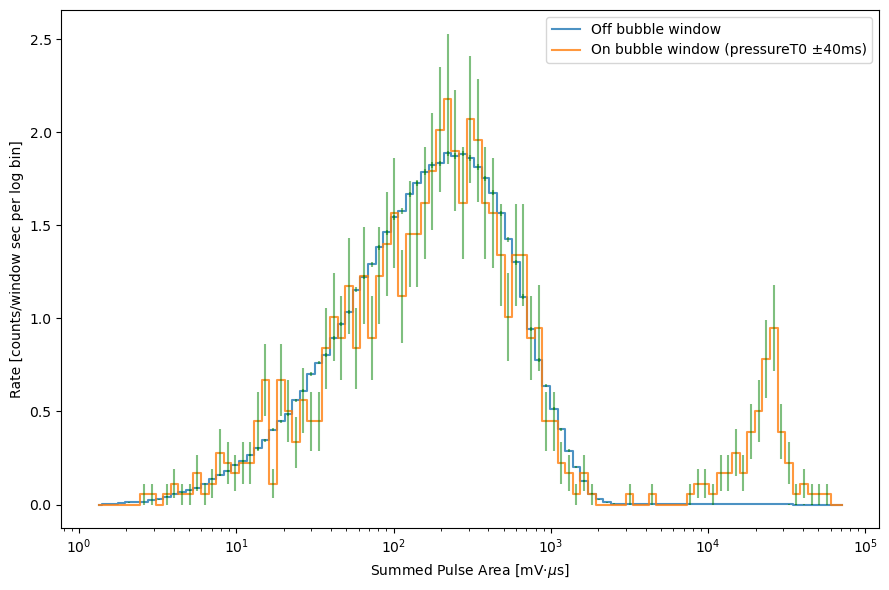

In [15]:

all_data = np.concatenate([off_bub_hits_bg, on_bub_hits_bg])
#all_data = all_data[np.isfinite(all_data) & (all_data > 8.77e-6)]
all_data = all_data[np.isfinite(all_data) & (all_data > 0)]
#print(all_data.min())
'''
bins = np.linspace(
    np.nanmin(all_data),
    np.nanmax(all_data),
    150
)
'''

bins = np.logspace(
    #np.log10(all_data.min()),
    0.1,
    0.1+np.log10(all_data.max()),
    100
)

'''
bins = np.logspace(
    np.log10(all_data.min())+2,
    #100,
    np.log10(all_data.max()),
    100
)
'''

off_bub_counts, _ = np.histogram(off_bub_hits_bg, bins=bins)
on_bub_counts, _ = np.histogram(on_bub_hits_bg, bins=bins)

'''
off_bub_rate = off_bub_counts / off_effective_livetime * 3600 
on_bub_rate = on_bub_counts / on_effective_livetime * 3600 
off_bub_rate_err = np.sqrt(off_bub_counts) / off_effective_livetime * 3600 
on_bub_rate_err = np.sqrt(on_bub_counts) / on_effective_livetime * 3600
'''

off_bub_rate = off_bub_counts / off_scint_livetime
on_bub_rate = on_bub_counts / on_scint_livetime

off_bub_rate_err = np.sqrt(off_bub_counts) / off_scint_livetime
on_bub_rate_err = np.sqrt(on_bub_counts) / on_scint_livetime

'''
off_bub_rate_err = off_bub_rate * np.sqrt(
    (np.sqrt(off_bub_counts) / off_bub_counts)**2 +
    (off_effective_livetime_err / off_effective_livetime)**2
)

on_bub_rate_err = on_bub_rate * np.sqrt(
    (np.sqrt(on_bub_counts) / on_bub_counts)**2 +
    (on_effective_livetime_err / on_effective_livetime)**2
)
'''

bin_centers = 0.5 * (bins[:-1] + bins[1:])
    


plt.figure(figsize=(9, 6))

plt.step(bin_centers, off_bub_rate, where="mid",label="Off bubble window", alpha=0.8)

plt.step(bin_centers, on_bub_rate, where="mid",label="On bubble window (pressureT0 ±40ms)", alpha=0.8)

plt.errorbar(
    bin_centers,
    off_bub_rate,
    yerr=off_bub_rate_err,
    ecolor = 'g',
    fmt='none',
    capsize=0,
    alpha=0.5
)

plt.errorbar(
    bin_centers,
    on_bub_rate,
    yerr=on_bub_rate_err,
    ecolor = 'g',
    fmt='none',
    capsize=0,
    alpha=0.5
)

#plt.axvline(2e3)
plt.xscale('log')
#plt.yscale('log')

#plt.axvline(6e3,color='black',linestyle='--')

plt.xlabel(r"Summed Pulse Area [mV$\cdot\mu$s]")
plt.ylabel("Rate [counts/window sec per log bin]")
#plt.title("Scintillation Triggers")
#plt.xlim(15,5e5)
plt.legend()
plt.tight_layout()

plt.savefig("ScintCoinc.png")

plt.show()


